In [1]:
import pandas as pd

# Load customer dataset
df = pd.read_csv("Customer_Transactions.csv")

# Display first 5 records
print(df.head())

  Customer_ID  Age  Gender  Annual_Income  Purchase_Frequency  Total_Spending  \
0        C001   22  Female          25000                   5           12000   
1        C002   35    Male          50000                  12           45000   
2        C003   28  Female          32000                   7           18000   
3        C004   45    Male          70000                  20           80000   
4        C005   31  Female          40000                  10           35000   

  Preferred_Category  
0            Fashion  
1        Electronics  
2             Beauty  
3        Electronics  
4            Grocery  


In [2]:
# Check missing values in each column
print(df.isnull().sum())

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Purchase_Frequency    0
Total_Spending        0
Preferred_Category    0
dtype: int64


In [4]:
# Fill missing values only in numeric columns

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].mean())
df['Purchase_Frequency'] = df['Purchase_Frequency'].fillna(df['Purchase_Frequency'].mean())
df['Total_Spending'] = df['Total_Spending'].fillna(df['Total_Spending'].mean())

print(df.isnull().sum())

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Purchase_Frequency    0
Total_Spending        0
Preferred_Category    0
dtype: int64


In [5]:
# Convert Gender column into numbers
# Male = 1, Female = 0

df['Gender'] = df['Gender'].map({
    'Male':1,
    'Female':0
})

print(df.head())

  Customer_ID  Age  Gender  Annual_Income  Purchase_Frequency  Total_Spending  \
0        C001   22       0          25000                   5           12000   
1        C002   35       1          50000                  12           45000   
2        C003   28       0          32000                   7           18000   
3        C004   45       1          70000                  20           80000   
4        C005   31       0          40000                  10           35000   

  Preferred_Category  
0            Fashion  
1        Electronics  
2             Beauty  
3        Electronics  
4            Grocery  


In [6]:
from sklearn.preprocessing import MinMaxScaler

# Select columns for normalization
columns = ['Annual_Income','Purchase_Frequency','Total_Spending']

# Create scaler object
scaler = MinMaxScaler()

# Apply normalization
df[columns] = scaler.fit_transform(df[columns])

print(df.head())

  Customer_ID  Age  Gender  Annual_Income  Purchase_Frequency  Total_Spending  \
0        C001   22       0       0.000000            0.047619        0.022222   
1        C002   35       1       0.416667            0.380952        0.388889   
2        C003   28       0       0.116667            0.142857        0.088889   
3        C004   45       1       0.750000            0.761905        0.777778   
4        C005   31       0       0.250000            0.285714        0.277778   

  Preferred_Category  
0            Fashion  
1        Electronics  
2             Beauty  
3        Electronics  
4            Grocery  


In [7]:
from sklearn.cluster import KMeans

# Features used for clustering
X = df[['Annual_Income',
        'Purchase_Frequency',
        'Total_Spending']]

# Create K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model and assign clusters
df['Cluster'] = kmeans.fit_predict(X)

# Display cluster results
print(df[['Customer_ID','Cluster']])

   Customer_ID  Cluster
0         C001        0
1         C002        1
2         C003        0
3         C004        2
4         C005        1
5         C006        0
6         C007        2
7         C008        2
8         C009        0
9         C010        1
10        C011        0
11        C012        2
12        C013        1
13        C014        0
14        C015        1


In [8]:
# Display customers and their clusters

for i in range(3):
    print("\nCluster", i)
    print(df[df['Cluster']==i])


Cluster 0
   Customer_ID  Age  Gender  Annual_Income  Purchase_Frequency  \
0         C001   22       0       0.000000            0.047619   
2         C003   28       0       0.116667            0.142857   
5         C006   24       1       0.050000            0.000000   
8         C009   27       0       0.083333            0.095238   
10        C011   29       0       0.166667            0.190476   
13        C014   26       1       0.033333            0.047619   

    Total_Spending Preferred_Category  Cluster  
0         0.022222            Fashion        0  
2         0.088889             Beauty        0  
5         0.000000            Fashion        0  
8         0.055556            Fashion        0  
10        0.133333             Beauty        0  
13        0.033333            Fashion        0  

Cluster 1
   Customer_ID  Age  Gender  Annual_Income  Purchase_Frequency  \
1         C002   35       1       0.416667            0.380952   
4         C005   31       0       0.2500

In [9]:
# Calculate average values for each cluster

cluster_summary = df.groupby('Cluster')[
    ['Annual_Income',
     'Purchase_Frequency',
     'Total_Spending']
].mean()

print(cluster_summary)

         Annual_Income  Purchase_Frequency  Total_Spending
Cluster                                                   
0             0.075000            0.087302        0.055556
1             0.416667            0.400000        0.411111
2             0.825000            0.821429        0.833333


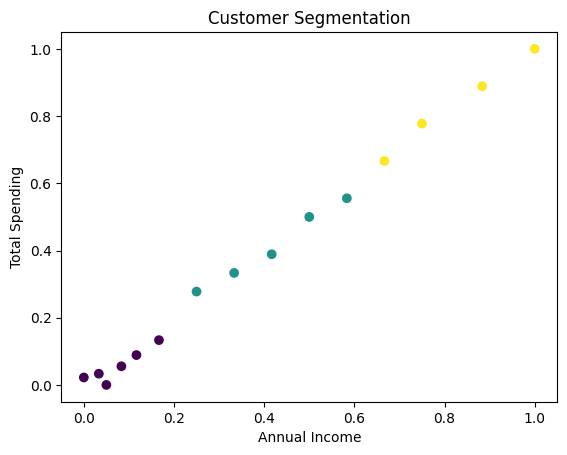

In [10]:
import matplotlib.pyplot as plt

# Scatter plot of customer segments

plt.scatter(
    df['Annual_Income'],
    df['Total_Spending'],
    c=df['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation")

plt.show()

# **Business Insights**

1.High-value customers spend more and help increase sales.

2.Low-value customers may buy more if given discounts.

3.Medium-value customers can become loyal customers.

4.Electronics customers spend more than others.

5.Customer groups help the company give better offers.